# One tSZ profile through the dataset engine, locally

This notebook runs **one row** of the 65,536-row pipeline in memory, on this machine, with the
frozen code of `tSZ_64k_flat_prior_SO_baseline_deproj0/` (the bundle the collaborator runs). It
shows every intermediate product that the dataset never stores:

1. the nine Battaglia+12 parameters (random from the flat prior, a design row, or the B12 fit),
2. the audited interpolation cache and the spherical (4 R200c) pressure column it represents,
3. the raw painted Compton-y map (NSIDE 8192 in production),
4. the map after the 2 arcmin Gaussian beam (NSIDE 4096 output),
5. the apodized f_sky = 0.4 cap mask and the masked map,
6. one SO baseline Deproj-0 noise realization and the masked signal + noise splits,
7. the three spectra the dataset keeps (full-sky clean, masked clean, masked noisy cross), the
   40-bin version, and a comparison with the 256-row test when a design row 0-255 is chosen.

**What is reused verbatim:** `engine/benchmark.jl`, `smooth_exterior.jl`,
`balanced_painter.jl`, `spherical_truncation_profiles.jl` and the HalfDome operators under
`halfdome_sources/` are `include`d unchanged. Two functions of `engine/engine.jl` are copied
into cells because that file also runs a production task on load: `probe_cache` (identical)
and `make_signal` (identical for the production preset; it only gains an `lmax` argument so
that the lower-resolution presets stay consistent). The test's command line
(`reference/test256/base_command.json`) is loaded the way `pipeline/common.py` does it, with
the same environment scrubbing.

**Nothing is written to disk** except a 1 kB operator-probe TOML in a temporary directory.
Maps live in memory only and are released as the notebook moves on.

| preset | raw NSIDE -> output | lmax | time on 20 threads | peak memory |
|---|---|---|---|---|
| `:production` | 8192 -> 4096 | 7979 | 13-31 min observed (painting dominates and the laptop CPU throttles) | about 14 GiB |
| `:preview` | 4096 -> 2048 | 6143 | 5-16 min observed | about 6 GiB |
| `:smoke` | 2048 -> 1024, halos > 1e13 Msun only | 3071 | about 2-6 min (mostly the first cold catalogue read) | about 3 GiB |

Only `:production` is the dataset engine; the other presets exist to look at maps quickly.
The flat prior is wide: some draws (design row 0, for instance) give skies five orders of magnitude
below the SO noise. `THETA_SOURCE = :battaglia12` shows the fiducial sky.
Kernel: *Julia 1.12.2 tSZ64k (20 threads)* (see `README.md` in this folder).

In [1]:
# ================================ SETTINGS ================================
# Environment variables HALFDOME_NB_PRESET / _THETA / _ROW / _SEEDS override the four choices below
# (used for unattended runs); otherwise edit the values here.
const REPO      = get(ENV, "HALFDOME_REPO", "/home/cbllover/HalfDome")
const BUNDLE    = joinpath(REPO, "tSZ_64k_flat_prior_SO_baseline_deproj0")
const ENGINE    = joinpath(BUNDLE, "engine")
const SOURCES   = joinpath(BUNDLE, "halfdome_sources")          # the FLAMINGO_CAMPAIGN directory of the 256-row test
const SO_DIR    = joinpath(SOURCES, "code", "halfdome", "other_sims", "SO")
const CATALOGUE = get(ENV, "HALFDOME_CATALOGUE", joinpath(REPO, "lightcone_100.hdf5"))
const TEST256   = joinpath(REPO, "SBI_analysis", "tsz_diagnostic_256_accelerated_20260922", "cluster_snapshot", "diagnostic_256")
const SCRATCH   = mktempdir()                                    # 1 kB operator probe only; deleted when the kernel exits

# Fidelity preset (table above). :production is exactly the dataset engine.
PRESET = Symbol(get(ENV, "HALFDOME_NB_PRESET", "preview"))
const PRESETS = Dict(
    :production => (nside_raw=8192, nside_out=4096, lmax=7979, mass_min=1.0e12),
    :preview    => (nside_raw=4096, nside_out=2048, lmax=6143, mass_min=1.0e12),
    :smoke      => (nside_raw=2048, nside_out=1024, lmax=3071, mass_min=1.0e13),
)
const P = PRESETS[PRESET]

# Pressure-profile parameters (nine Battaglia+12 parameters, physical values):
#   :random      independent uniforms inside the flat prior of the 64k design, drawn from RANDOM_SEED
#   :design_row  row DESIGN_ROW (0-based) of design/theta_design_65536.npy; rows 0-255 are the 256-row test
#   :battaglia12 the Battaglia+12 fit
THETA_SOURCE = Symbol(get(ENV, "HALFDOME_NB_THETA", "random"))
DESIGN_ROW   = parse(Int, get(ENV, "HALFDOME_NB_ROW", "0"))
RANDOM_SEED  = 20260925

# Seeds of the two SO noise splits:
#   :test256    the seeds the 256-row test used for DESIGN_ROW (rows 0-255): noise maps then match the test bitwise
#   :design64k  the seeds of the 65,536-row design for DESIGN_ROW: what the collaborator's dataset uses
#   :random     two seeds drawn from RANDOM_SEED
NOISE_SEEDS = Symbol(get(ENV, "HALFDOME_NB_SEEDS", "random"))
println("preset $PRESET: NSIDE $(P.nside_raw) -> $(P.nside_out), lmax $(P.lmax), mass_min $(P.mass_min); theta = $THETA_SOURCE, row $DESIGN_ROW, noise seeds = $NOISE_SEEDS")

preset preview: NSIDE 4096 -> 2048, lmax 6143, mass_min 1.0e12; theta = battaglia12, row 0, noise seeds = random


In [2]:
# ============== the test's command line and environment (pipeline/common.py: build_command, scrubbed_environment) ==============
using Printf, Random, Statistics, LinearAlgebra, TOML, SHA
ENV["GKSwstype"] = "100"                      # headless GR for the inline plots
using Plots
Plots.default(fmt=:png, dpi=110)             # PNG only: keeps the notebook small (no inline SVG copies of the maps)
@assert isfile(joinpath(ENGINE, "engine.jl")) "bundle not found at $BUNDLE (set ENV[\"HALFDOME_REPO\"])"
@assert isfile(CATALOGUE) "HalfDome catalogue not found at $CATALOGUE (set ENV[\"HALFDOME_CATALOGUE\"])"
println("Julia ", VERSION, ", ", Threads.nthreads(), " threads, ", round(Sys.free_memory() / 2^30; digits=1), " GiB free of ",
        round(Sys.total_memory() / 2^30; digits=1), " GiB")
Threads.nthreads() >= 8 || @warn "The kernel has few threads; painting is threaded (the kernel spec uses --threads=20)."

# The argv of the 256-row test (reference/test256/base_command.json) with local paths, exactly as common.py builds it.
function test_argv()
    lines = readlines(joinpath(BUNDLE, "reference", "test256", "base_command.json"))
    start = findfirst(l -> occursin("\"argv\"", l), lines)
    argv = String[]
    for line in lines[start+1:end]
        m = match(r"^\s*\"(.*)\",?\s*$", line)
        m === nothing && break
        push!(argv, m.captures[1])
    end
    return argv
end
args = String[]
for value in test_argv()[2:end]
    startswith(value, "--") && continue                  # --startup-file, --threads, --project are kernel settings here
    endswith(value, "/gate.jl") && continue              # the script argument; this notebook plays that role
    if startswith(value, "halfdome_path=")
        value = "halfdome_path=" * CATALOGUE
    elseif startswith(value, "output_dir=")
        value = "output_dir=" * joinpath(SCRATCH, "raw")
    elseif startswith(value, "cache_dir=")
        value = "cache_dir=" * joinpath(SCRATCH, "cache")
    elseif startswith(value, "baseline_noise_path=") || startswith(value, "goal_noise_path=")
        key, original = split(value, "="; limit=2)
        value = key * "=" * joinpath(SO_DIR, basename(original))
    end
    occursin("/lustre/", value) && error("unhandled test path in base_command.json: $value")
    push!(args, value)
end
# Preset values; for :production every one of them equals the test's value.
for (key, new) in ("nside" => P.nside_raw, "cl_lmax" => P.lmax, "so_noise_lmax" => P.lmax, "mass_min" => P.mass_min)
    i = findfirst(a -> startswith(a, key * "="), args)
    args[i] = "$key=$new"
end
empty!(ARGS); append!(ARGS, args)

# The HalfDome configuration gives environment variables precedence over key=value arguments, so remove every
# variable the frozen sources read (same regular expression and rules as common.py).
const ENV_PATTERN = r"env\s*=\s*\"([A-Z][A-Z0-9_]*)\"|ENV\[\"([A-Z][A-Z0-9_]*)\"\]|haskey\(ENV,\s*\"([A-Z][A-Z0-9_]*)\"\)|get\(ENV,\s*\"([A-Z][A-Z0-9_]*)\""
sources = vcat(filter(p -> endswith(p, ".jl"), readdir(ENGINE; join=true)),
               [joinpath(root, f) for (root, _, files) in walkdir(SOURCES) for f in files if endswith(f, ".jl")])
read_names = Set{String}()
for path in sources, m in eachmatch(ENV_PATTERN, read(path, String)), c in m.captures
    c === nothing || push!(read_names, c)
end
removed = String[]
for key in collect(keys(ENV))
    if (key in read_names && !(key in ("SLURM_JOB_ID", "SLURM_ARRAY_TASK_ID"))) || key in ("JULIA_PROJECT", "JULIA_LOAD_PATH") ||
       startswith(key, "TSZ_") || startswith(key, "BATTAGLIA_") || startswith(key, "BARYON_SLICE_")
        delete!(ENV, key); push!(removed, key)
    end
end
isempty(removed) || println("removed from ENV (would override the command line): ", join(sort(removed), ", "))
ENV["JULIA_DEPOT_PATH"]     = join(DEPOT_PATH, ":")
ENV["FLAMINGO_CAMPAIGN"]    = SOURCES
ENV["HALFDOME_SOURCE_DIR"]  = joinpath(SOURCES, "code", "halfdome")
ENV["PREFLIGHT_OUTPUT"]     = SCRATCH
ENV["HALO_BLOCK_SIZE"]      = "256"
ENV["OPENBLAS_NUM_THREADS"] = "1"; ENV["MKL_NUM_THREADS"] = "1"; ENV["OMP_NUM_THREADS"] = string(Threads.nthreads())
ENV["HDF5_USE_FILE_LOCKING"] = "FALSE"
ENV["BENCHMARK_LOAD_ONLY"]  = "1"          # engine.jl sets this before including benchmark.jl
println(length(ARGS), " arguments prepared")

Julia 1

.12.2, 20 threads, 29.1 GiB free of 31.2 GiB


removed from ENV (would override the command line): JULIA_DEPOT_PATH


68 arguments prepared


In [3]:
# ============== load the frozen engine (the include list of engine.jl, in its order) ==============
# benchmark.jl includes fullsky_test.jl, which includes process_maps.jl (-> run_halfdome_fullsky_so_noise.jl -> the
# HalfDome tSZ operators) and spherical_truncation_profiles.jl. process_maps.jl runs its small operator probe on load.
include(joinpath(ENGINE, "benchmark.jl"))
include(joinpath(ENGINE, "smooth_exterior.jl"))
include(joinpath(ENGINE, "balanced_painter.jl"))
println("engine loaded; XGPaint from ", pathof(XGPaint))

Small operator probe passed: /tmp/jl_Vat73P/operator_probe.toml
engine loaded; XGPaint from 

/home/kn18001/.julia/packages/XGPaint/U6YjI/src/XGPaint.jl


In [4]:
# ============== small helpers local to this notebook (display, npy reading, binning) ==============
function read_npy(path)                       # float64 / int64 .npy files, C order
    open(path) do io
        @assert read(io, 6) == UInt8[0x93, UInt8.(collect("NUMPY"))...] "not a .npy file: $path"
        major = read(io, UInt8); read(io, UInt8)
        hlen = major == 1 ? Int(ltoh(read(io, UInt16))) : Int(ltoh(read(io, UInt32)))
        header = String(read(io, hlen))
        descr = match(r"'descr':\s*'([^']+)'", header).captures[1]
        T = descr == "<f8" ? Float64 : descr == "<i8" ? Int64 : error("unsupported npy dtype $descr")
        dims = parse.(Int, filter(!isempty, strip.(split(match(r"'shape':\s*\(([^)]*)\)", header).captures[1], ','))))
        data = read!(io, Vector{T}(undef, prod(dims)))
        length(dims) == 1 ? data : permutedims(reshape(data, reverse(dims)...))
    end
end

dl_factor(ell) = ell .* (ell .+ 1) ./ (2pi)
# 40 bins of 200 multipoles from ell = 80 (last bin to 7979), weights 2l+1: manage.py rebin_unbinned / the 256-row test.
function rebin40(cl; lmax=min(7979, length(cl) - 1))
    edges = vcat(80:200:7880, 7980)
    ell = 80:lmax
    dl = cl[ell .+ 1] .* dl_factor(ell)
    centres = Float64[]; values = Float64[]
    for (a, b) in zip(edges[1:end-1], edges[2:end])
        sel = (ell .>= a) .& (ell .< b)
        any(sel) || continue
        w = 2 .* ell[sel] .+ 1
        push!(centres, (a + min(b, lmax + 1) - 1) / 2); push!(values, sum(w .* dl[sel]) / sum(w))
    end
    return centres, values
end

# Full-sky views use an NSIDE-512 equal-area average (average_children of benchmark.jl); zooms read the full-resolution map.
coarse_view(m; nside=512) = m.resolution.nside <= nside ? m : average_children(m, nside)
function sym_clims(img)
    finite = filter(isfinite, vec(img))
    isempty(finite) && return nothing
    q = quantile(abs.(finite), 0.995)
    return q > 0 ? (-q, q) : nothing         # an all-zero window (fully masked) leaves the colour range automatic
end
valid_clims(c) = c === nothing ? nothing : (all(isfinite, c) && c[1] != c[2]) ? c : nothing
function log_range(img)                       # display range of a log map from its positive pixels (2 % .. 99.99 %)
    pos = filter(x -> isfinite(x) && x > 0, vec(img))
    isempty(pos) && return (1e-12, 1e-11)
    lo, hi = quantile(pos, 0.02), quantile(pos, 0.9999)
    hi > lo || (hi = 10lo)
    return (lo, hi)
end
function prepare_image(img, log, symmetric, clims, scale)
    if log
        lo, hi = log_range(img)
        clims === nothing && (clims = (log10(lo), log10(hi)))
        return log10.(max.(img, lo)), valid_clims(clims), "log10 y"
    end
    img = img .* scale                        # linear maps are shown in units of 1/scale (1e-6 by default)
    symmetric && (clims = sym_clims(img))
    return img, valid_clims(clims), scale == 1 ? "" : @sprintf("y / %.0e", 1 / scale)
end
function show_map(m; title="", log=true, symmetric=false, clims=nothing, scale=1e6, width=1000, cmap=:inferno)
    img = Healpix.mollweide(coarse_view(m), Dict(:width => width))[1]
    img, clims, label = prepare_image(img, log, symmetric, clims, scale)
    kw = clims === nothing ? (;) : (; clims=clims)
    heatmap(img; yflip=false, aspect_ratio=:equal, axis=false, grid=false, ticks=false, c=cmap, title=title,
            colorbar_title=label, size=(width, width ÷ 2 + 70), margin=3Plots.mm, kw...)
end
function brightest_direction(m; support=nothing)   # (latitude, longitude) in radians of the brightest NSIDE-512 pixel
    c = coarse_view(m)
    values = support === nothing ? c.pixels : c.pixels .* (coarse_view(support).pixels .> 0.99)   # well inside the mask
    theta, phi = Healpix.pix2angRing(c.resolution, argmax(values))
    return (pi / 2 - theta, phi)
end
# Send PNG only to the notebook (Plots would otherwise also render an SVG copy of every map, slowly and at 5x the size).
show_png(p) = (isdefined(Main, :IJulia) ? display(MIME("image/png"), p) : display(p); nothing)
# Healpix.gnomonic's :center is not (latitude, longitude): its rotation puts the image centre along
# (cos phi1 cos lambda0, sin lambda0, -sin phi1 cos lambda0). Invert that for the wanted direction.
function gnomonic_centre(lat, lon)
    nx, ny, nz = cos(lat) * cos(lon), cos(lat) * sin(lon), sin(lat)
    return (atan(-nz, nx), asin(clamp(ny, -1.0, 1.0)), 0.0)
end
function show_zoom(m, centre; fov_deg=3.0, title="", log=true, symmetric=false, clims=nothing, scale=1e6, width=480, cmap=:inferno)
    img = Healpix.gnomonic(m, Dict(:center => gnomonic_centre(centre...), :fov_rad => deg2rad(fov_deg), :width => width))[1]
    img, clims, label = prepare_image(img, log, symmetric, clims, scale)
    kw = clims === nothing ? (;) : (; clims=clims)
    heatmap(img; yflip=false, aspect_ratio=:equal, axis=false, grid=false, ticks=false, c=cmap, title=title,
            colorbar_title=label, size=(width + 90, width), margin=3Plots.mm, kw...)
end
mem() = @sprintf("%.1f GiB free of %.1f GiB", Sys.free_memory() / 2^30, Sys.total_memory() / 2^30)
println("helpers defined; ", mem())

helpers defined; 28.4 GiB free of 31.2 GiB

In [5]:
# ============== 1. parameters and noise seeds ==============
const PARAMETER_NAMES = ["P0", "xc", "beta", "alpha_m_P0", "alpha_m_xc", "alpha_m_beta", "alpha_z_P0", "alpha_z_xc", "alpha_z_beta"]
const LOWER = [1.0, 0.025, 2.8, -0.6, -1.0, -0.2, -6.0, -1.5, -0.5]      # design/design_manifest.json (flat prior)
const UPPER = [60.0, 4.0, 16.0, 1.5, 0.4, 0.4, 0.5, 3.0, 2.0]
const BATTAGLIA12 = [18.1, 0.497, 4.35, 0.154, -0.00865, 0.0393, -0.758, 0.731, 0.415]
design_theta = read_npy(joinpath(BUNDLE, "design", "theta_design_65536.npy"))
design_seeds = read_npy(joinpath(BUNDLE, "design", "noise_seeds_65536.npy"))
@assert size(design_theta) == (65536, 9) && size(design_seeds) == (65536, 2)
rng = MersenneTwister(RANDOM_SEED)
theta = THETA_SOURCE == :random      ? LOWER .+ (UPPER .- LOWER) .* rand(rng, 9) :
        THETA_SOURCE == :design_row  ? vec(design_theta[DESIGN_ROW + 1, :]) :
        THETA_SOURCE == :battaglia12 ? copy(BATTAGLIA12) : error("THETA_SOURCE = $THETA_SOURCE")
@assert all(LOWER .<= theta .<= UPPER) "theta is outside the flat prior"
seeds = NOISE_SEEDS == :random    ? rand(rng, 1:(typemax(Int) ÷ 2), 2) :
        NOISE_SEEDS == :design64k ? vec(design_seeds[DESIGN_ROW + 1, :]) :
        NOISE_SEEDS == :test256   ? (DESIGN_ROW < 256 ? vec(read_npy(joinpath(BUNDLE, "reference", "test256", "noise_seeds.npy"))[DESIGN_ROW + 1, :]) :
                                     error("the 256-row test has seeds for rows 0-255 only")) : error("NOISE_SEEDS = $NOISE_SEEDS")
@assert seeds[1] != seeds[2]
println("theta ($THETA_SOURCE", THETA_SOURCE == :design_row ? " $DESIGN_ROW" : "", "):")
for (name, value, lo, hi) in zip(PARAMETER_NAMES, theta, LOWER, UPPER)
    @printf("  %-13s %10.5f   prior [%g, %g]\n", name, value, lo, hi)
end
println("noise seeds ($NOISE_SEEDS): ", seeds)

theta (battaglia12

):
  P0              18.10000   prior [1, 60]
  xc               0.49700   prior [0.025, 4]


  beta             4.35000   prior [2.8, 16]
  alpha_m_P0       0.15400   prior [-0.6, 1.5]
  alpha_m_xc      -0.00865   prior [-1, 0.4]
  alpha_m_beta     0.03930   prior [-0.2, 0.4]
  alpha_z_P0      -0.75800   prior [-6, 0.5]
  alpha_z_xc       0.73100   prior [-1.5, 3]
  alpha_z_beta     0.41500   prior [-0.5, 2]
noise seeds (random): 

[390273546850147024, 3554310736205426296]


In [6]:
# ============== 2. configuration (benchmark.jl configure -> load_halfdome_fullsky_so_noise_config) ==============
cfg  = configure(theta)
base = cfg.base_cfg
@assert base.nside == P.nside_raw && base.cl_lmax == P.lmax && base.cl_niter == 0 && base.batching_mode == "full"
@assert base.gaussian_beam_fwhm_arcmin == 2.0 && base.interpolator_pad == 256 && base.mass_min == P.mass_min && base.apply_mass_cut
@assert cfg.fsky == 0.4 && cfg.mask_seed == 12345 && cfg.mask_apodization_arcmin == 60.0 && cfg.noise_deprojection == 0
println("\ncatalogue:   ", base.halfdome_path, "\nnoise table: ", cfg.baseline_noise_path,
        "\ncosmology:   h=", base.cosmo_h, " Omega_b=", base.cosmo_omegab, " Omega_c=", base.cosmo_omegac)


catalogue:   /home/cbllover/HalfDome/lightcone_100.hdf5


noise table: /home/cbllover/HalfDome/tSZ_64k_flat_prior_SO_baseline_deproj0/halfdome_sources/code/halfdome/other_sims/SO/SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt
cosmology:   h=0.68 Omega_b=0.049 Omega_c=0.261


In [7]:
# ============== 3. interpolation cache with the engine's accuracy audit ==============
# engine.jl audit_profiles: build the 256 x 128 x 64 log(theta) x log(z) x log10(M) chord-mean cache, probe it against
# direct spherical-column integrals at 2,496 points, refine to 512x256x128 and 1024x512x256 until the visible relative
# error and the error scaled by the central column are both below 0.4 %. probe_cache is copied verbatim from engine.jl.
function probe_cache(profile)
    max_relative = 0.; max_scaled = 0.; squared = 0.; denominator = 0.
    probes = Vector{Vector{Float64}}()
    for lm in [12.013,12.53,13.07,13.61,14.13,14.69,15.19,15.67],
        z in [.00113,.0037,.0127,.047,.173,.61,1.73,4.71]
        mass = 10.0^lm
        p = XGPaint.prepare_profile_slice(profile.model,mass,z)
        central = spherical_value_direct(profile.model,0.,mass,z)
        @assert isfinite(central) && central>0
        for x in vcat(10.0.^range(-7.,log10(3.5),length=36),[3.8,3.98,3.9998])
            theta = max(x*p.θ200,exp(first(profile.itp.ranges[1])))
            direct = spherical_value_direct(profile.model,theta,mass,z)
            estimated = profile(theta,mass,z)*chord_factor(theta,4p.θ200,4.)
            @assert isfinite(estimated) && estimated>=0 && isfinite(direct)
            scaled = abs(estimated-direct)/central
            max_scaled = max(max_scaled,scaled)
            if direct > central*1e-5
                max_relative = max(max_relative,abs(estimated/direct-1))
            end
            squared += (estimated-direct)^2; denominator += direct^2
            push!(probes,[lm,z,x,direct,estimated,central])
        end
    end
    return Dict{String,Any}("max_relative_visible"=>max_relative,"max_absolute_over_central"=>max_scaled,
        "relative_l2"=>sqrt(squared/denominator),"points"=>length(probes)),probes
end

audit = Dict{String,Any}[]
profile = nothing
accepted = false
for nodes in [[256, 128, 64], [512, 256, 128], [1024, 512, 256]]
    started = time()
    global profile = build_cache(base, nodes)
    metrics, _ = probe_cache(profile)
    metrics["nodes"] = nodes; metrics["seconds"] = time() - started
    push!(audit, metrics)
    @printf("cache %4d x %3d x %3d: max relative (visible) %.2e, max |error|/central %.2e, relative L2 %.2e, %d points, %.1f s\n",
            nodes..., metrics["max_relative_visible"], metrics["max_absolute_over_central"], metrics["relative_l2"], metrics["points"], metrics["seconds"])
    if metrics["max_relative_visible"] <= .004 && metrics["max_absolute_over_central"] <= .004
        global accepted = true
        break
    end
    global profile = nothing; GC.gc()
end
accepted || error("no cache grid met the 0.4 % target: the dataset pipeline defers such a row instead of painting it")
println("accepted grid: ", audit[end]["nodes"])

[interpolator] profile_grid dims: N_logtheta=256

 N_z=128 N_logM=64 threads=20


[interpolator] START profile_grid allocation


[interpolator] END   profile_grid allocation wall=0.013 s size=(256, 128, 64) eltype=Float64


[interpolator] START profile_grid threaded evaluation


[interpolator] END   profile_grid threaded evaluation wall=2.407 s


cache  256 x 128 x  64: max relative (visible) 2.41e-04, max |error|/central 1.94e-05, relative L2 1.83e-05, 2496 points, 9.1 s
accepted grid: 

[256, 128, 64]


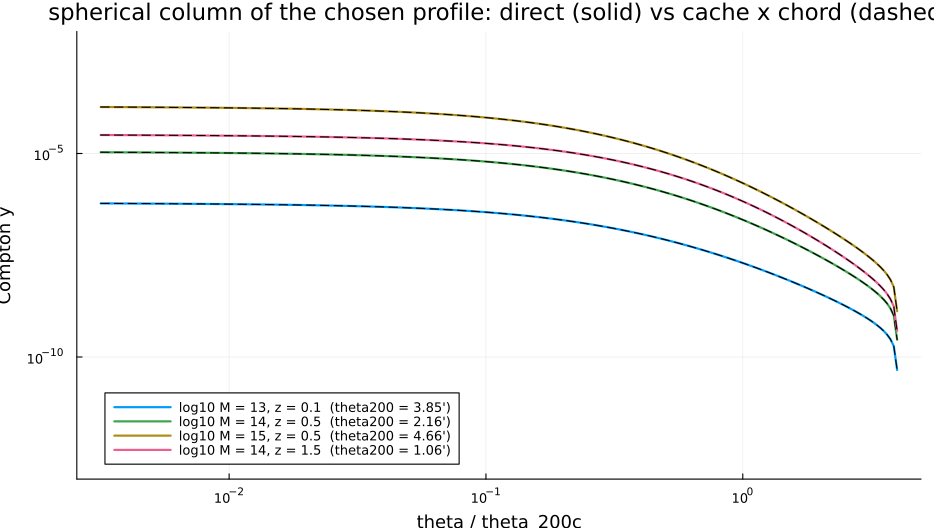

In [8]:
# ============== the pressure column this cache represents ==============
# Compton-y column through the 4 R200c sphere (chord-limited line of sight) for a few halo masses and redshifts:
# direct quadrature (spherical_value_direct) against the cache multiplied by the exact chord factor, as the painter uses it.
let xs = 10 .^ range(-2.5, log10(3.99), length=240)
    plt = plot(xscale=:log10, yscale=:log10, xlabel="theta / theta_200c", ylabel="Compton y", legend=:bottomleft, size=(850, 480),
               title="spherical column of the chosen profile: direct (solid) vs cache x chord (dashed)", ylims=(1e-13, 1e-2))
    for (lm, z) in [(13.0, 0.1), (14.0, 0.5), (15.0, 0.5), (14.0, 1.5)]
        mass = 10.0^lm
        p = XGPaint.prepare_profile_slice(profile.model, mass, z)
        theta_min = exp(first(profile.itp.ranges[1]))
        direct = [spherical_value_direct(profile.model, x * p.θ200, mass, z) for x in xs]
        cached = [profile(max(x * p.θ200, theta_min), mass, z) * chord_factor(x * p.θ200, 4p.θ200, 4.) for x in xs]
        plot!(plt, xs, max.(direct, 1e-30), label=@sprintf("log10 M = %.0f, z = %.1f  (theta200 = %.2f')", lm, z, rad2deg(p.θ200) * 60), lw=2)
        plot!(plt, xs, max.(cached, 1e-30), label="", ls=:dash, color=:black, lw=1)
    end
    show_png(plt)
end

before painting: 28.0 GiB free of 31.2 GiB


CHUNK 1:2000000 selected=2000000 elapsed_read=1.264843225479126 elapsed_paint=2.3607850074768066


CHUNK 2000001:4000000 selected=4000000 elapsed_read=1.4382274150848389 elapsed_paint=4.946502923965454


CHUNK 4000001:6000000 selected=6000000 elapsed_read=1.5550415515899658 elapsed_paint=7.4889538288116455


CHUNK 6000001:8000000 selected=8000000 elapsed_read=1.700122594833374 elapsed_paint=9.79714584350586


...

CHUNK 78000001:80000000 selected=80000000 elapsed_read=5.515859842300415 elapsed_paint=134.52061796188354


CHUNK 80000001:82000000 selected=82000000 elapsed_read=5.596998929977417 elapsed_paint=143.2739179134369


CHUNK 82000001:84000000 selected=84000000 elapsed_read=5.669526815414429 elapsed_paint=154.35921788215637


CHUNK 84000001:85224251 selected=85224251 elapsed_read=5.719278812408447 elapsed_paint=179.37275195121765



painted 85224251 halos in 187 s (catalogue reads 6 s, painting 179 s)
raw map NSIDE 4096: mean y = 1.020e-06, max y = 4.712e-04; 26.1 GiB free of 31.2 GiB


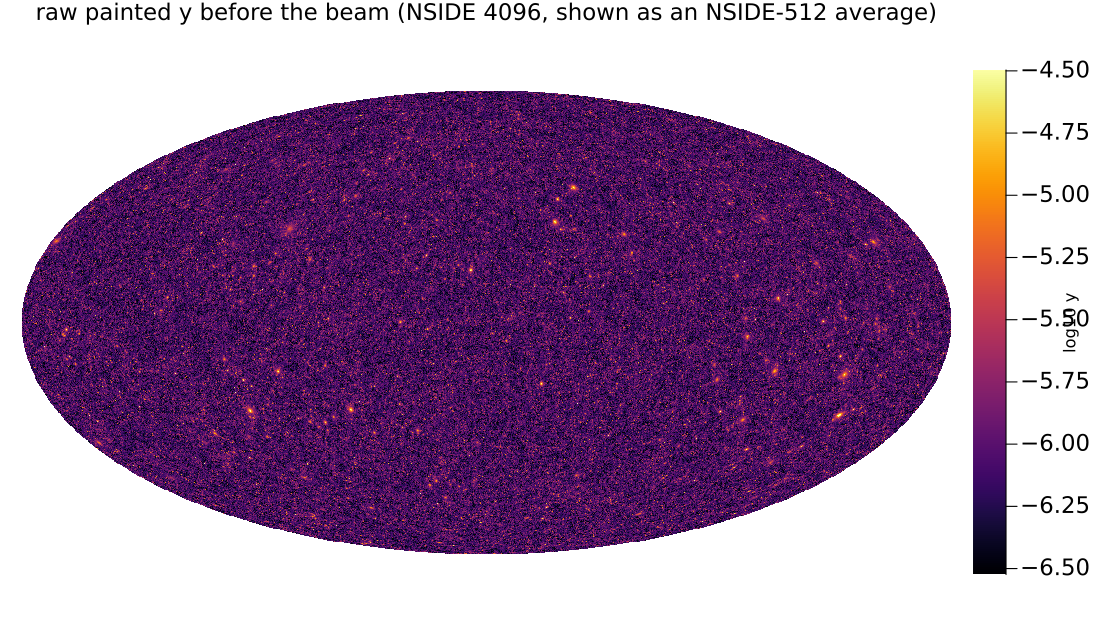

In [9]:
# ============== 4. paint the raw map (catalogue_pass! + paint_shared!, one catalogue pass) ==============
println("before painting: ", mem())
state = blank_state(P.nside_raw)
let warm = [blank_state(32)]                  # compile the painting kernel on a tiny map, as the engine does
    paint_shared!(warm, [profile], [1. 0.; 0. 1.; 0. 0.], [1e15, 1e15], [.01, .01])
end
GC.gc()
started = time()
count = catalogue_pass!(base, [state], [profile]; shared_geometry=true)
P.mass_min == 1.0e12 && @assert count == 85224251 "the engine stops for any other selected-halo count"
@printf("\npainted %d halos in %.0f s (catalogue reads %.0f s, painting %.0f s)\nraw map NSIDE %d: mean y = %.3e, max y = %.3e; %s\n",
        count, time() - started, TIMINGS["read_mass_redshift"] + TIMINGS["read_positions"], TIMINGS["painting"],
        P.nside_raw, mean(state.m_hp.pixels), maximum(state.m_hp.pixels), mem())
centre = brightest_direction(state.m_hp)      # zoom target: the brightest region of the sky
show_png(show_map(state.m_hp; title="raw painted y before the beam (NSIDE $(P.nside_raw), shown as an NSIDE-512 average)"))

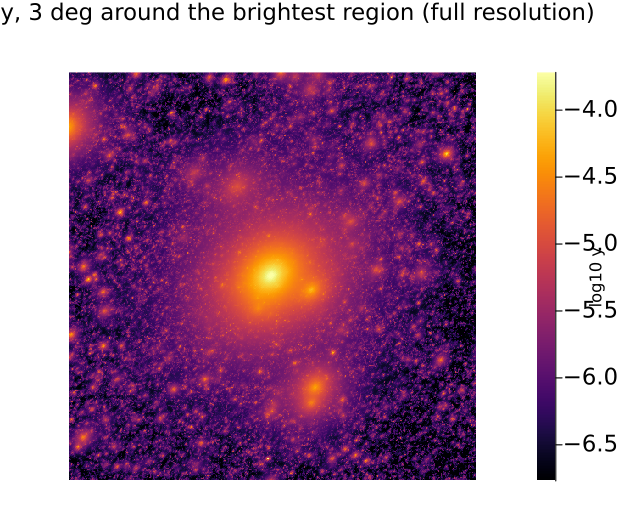

In [10]:
show_png(show_zoom(state.m_hp, centre; fov_deg=3.0, title="raw y, 3 deg around the brightest region (full resolution)"))

beamed signal NSIDE 2048: mean y = 1.020e-06, max y = 2.424e-04 (map2alm 16 s, alm2map 9 s); 26.0 GiB free of 31.2 GiB
Computing C_l with lmax=6143, niter=0.

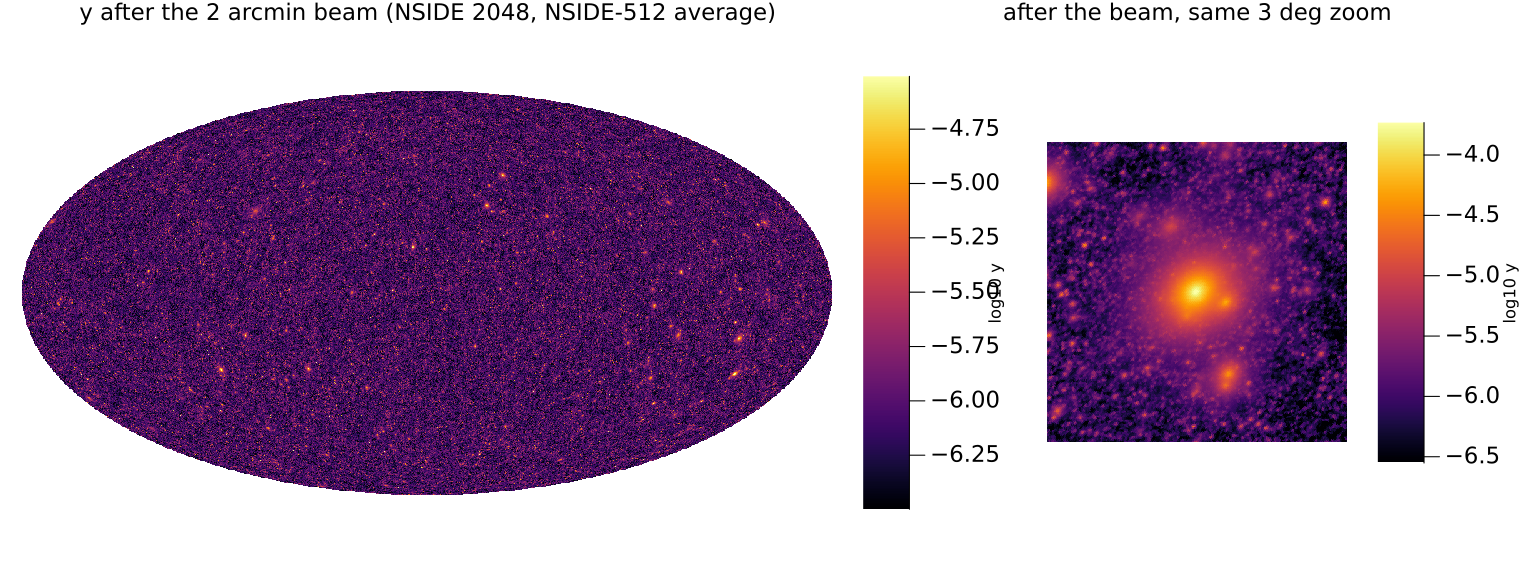

In [11]:
# ============== 5. Gaussian beam (engine.jl make_signal) ==============
# map2alm of the raw map to lmax 12287 (the NSIDE-8192 default), 2 arcmin FWHM Gaussian beam, synthesis at the output NSIDE.
# The lmax argument equals the engine's fixed 12287 for :production and :preview; it is lowered only for :smoke.
function make_signal(raw, output_nside; lmax=min(12287, 3 * raw.resolution.nside - 1))
    alm = measure("raw_map2alm") do
        Healpix.map2alm(raw; lmax=lmax, niter=0)
    end
    Healpix.almxfl!(alm, Healpix.gaussbeam(deg2rad(2/60), alm.lmax))
    return measure("signal_alm2map") do
        Healpix.alm2map(alm, output_nside)
    end
end
signal = make_signal(state.m_hp, P.nside_out)
state = nothing; GC.gc()                      # the raw map is released here
@printf("beamed signal NSIDE %d: mean y = %.3e, max y = %.3e (map2alm %.0f s, alm2map %.0f s); %s\n",
        P.nside_out, mean(signal.pixels), maximum(signal.pixels), TIMINGS["raw_map2alm"], TIMINGS["signal_alm2map"], mem())
cl_unmasked = compute_cl(base, signal)        # save_observation: unmasked_clean_cl.npy
show_png(plot(show_map(signal; title="y after the 2 arcmin beam (NSIDE $(P.nside_out), NSIDE-512 average)"),
              show_zoom(signal, centre; title="after the beam, same 3 deg zoom"); layout=grid(1, 2, widths=[0.68, 0.32]), size=(1400, 520)))

mask: support f_sky = 0.4000, <w> = 0.3957, <w^2> = 0.3947, cap centre (lat, lon) = (35.9, -24.7) deg
Computing C_l with lmax=6143, niter=0.

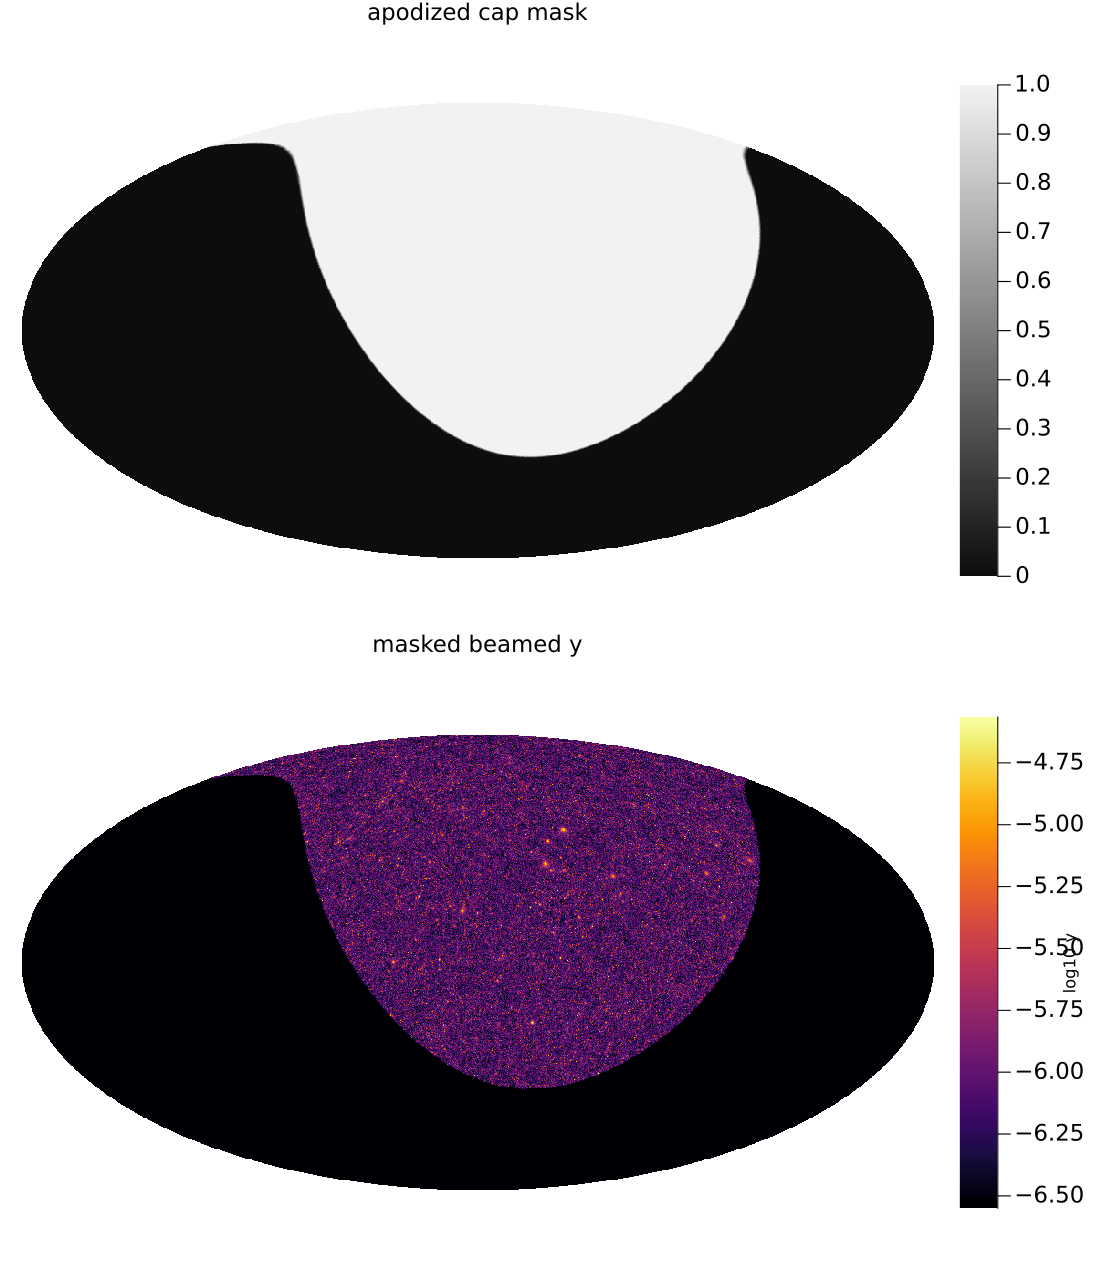

In [12]:
# ============== 6. mask (save_observation: apodized cap, f_sky 0.4, 60 arcmin apodization, seed 12345) ==============
mask_info = random_apodized_cap_mask(P.nside_out, .4, 60., MersenneTwister(12345))
mask = mask_info.mask
mask_sha = pixel_sha(mask)
@printf("mask: support f_sky = %.4f, <w> = %.4f, <w^2> = %.4f, cap centre (lat, lon) = (%.1f, %.1f) deg\n",
        mask_info.support_fsky, mask_info.mean_weight, mask_info.mean_weight2,
        rad2deg(asin(mask_info.center.z)), rad2deg(atan(mask_info.center.y, mask_info.center.x)))
P.nside_out == 4096 && println("mask SHA-256 ", mask_sha[1:12], mask_sha == "a6c3d64d5ab83e79b6d9b76cccbaf66a708c3e68adce85b9a0d3f610d4100689" ?
                               ": identical to the dataset mask" : ": DIFFERS from the dataset mask a6c3d64d...")
signal.pixels .*= mask.pixels                 # in place, as save_observation does
cl_masked = compute_cl(base, signal)          # save_observation: masked_clean_cl.npy
centre_masked = brightest_direction(signal; support=mask)   # brightest region well inside the mask, for the zooms below
show_png(plot(show_map(mask; title="apodized cap mask", log=false, cmap=:grays, clims=(0, 1), scale=1),
              show_map(signal; title="masked beamed y"); layout=(2, 1), size=(1000, 1150)))

noise splits NSIDE 2048, lmax 6143: pixel rms 3.212e-06 and 3.212e-06; 25.3 GiB free of 31.2 GiB
Computing C_l with lmax=6143, niter=0.

Computing cross C_l with lmax=6143, niter=0.


Computing C_l with lmax=6143, niter=0.


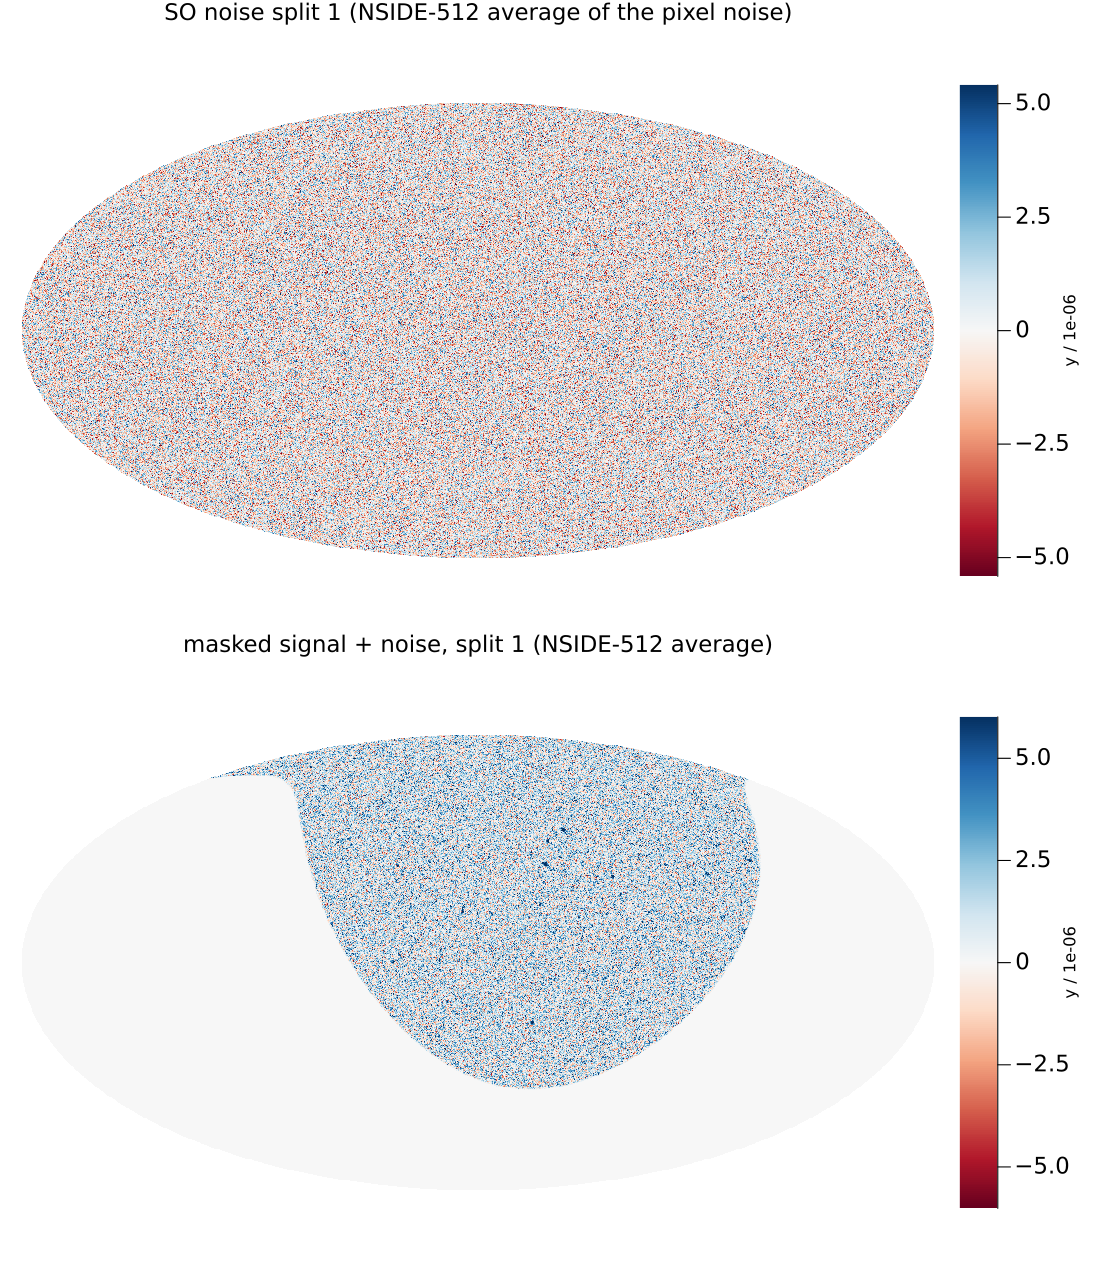

In [13]:
# ============== 7. SO noise: two independent splits (save_observation) ==============
# The SO LAT baseline Deproj-0 N_ell (column 2 of the table) is used as is: no signal-beam factor on the noise. One
# Gaussian realization per split from its own seed; the observation keeps (noise * mask) + masked signal per split.
ell_native, native = read_so_noise_native_cl(cfg.baseline_noise_path, P.lmax; column=2, input_is_dl=false)
noise_cl = so_noise_cl_vector_for_synalm(ell_native, native, P.lmax)
splits = [generate_gaussian_noise_map(noise_cl, P.nside_out, P.lmax, MersenneTwister(s)) for s in seeds]
noise_hashes = pixel_sha.(splits)
@assert noise_hashes[1] != noise_hashes[2]
@printf("noise splits NSIDE %d, lmax %d: pixel rms %.3e and %.3e; %s\n", P.nside_out, P.lmax, std(splits[1].pixels), std(splits[2].pixels), mem())
cl_noise_auto = compute_cl(base, splits[1])   # illustration only: full-sky auto-spectrum of one noise split
noise_view = show_map(splits[1]; title="SO noise split 1 (NSIDE-512 average of the pixel noise)", log=false, cmap=:RdBu, symmetric=true)
for split in splits
    split.pixels .= split.pixels .* mask.pixels .+ signal.pixels
end
cl_cross = compute_cross_cl(base, splits[1], splits[2])      # save_observation: masked_noisy_cross_cl.npy (signed)
cl_auto1 = compute_cl(base, splits[1])                       # illustration only: one split's auto-spectrum (noise-biased)
@assert all(isfinite, cl_cross)
show_png(plot(noise_view,
              show_map(splits[1]; title="masked signal + noise, split 1 (NSIDE-512 average)", log=false, cmap=:RdBu, symmetric=true);
              layout=(2, 1), size=(1000, 1150)))

zoom centre (lat, lon) = (74.6, 75.8) deg; mask weight there = 1.000


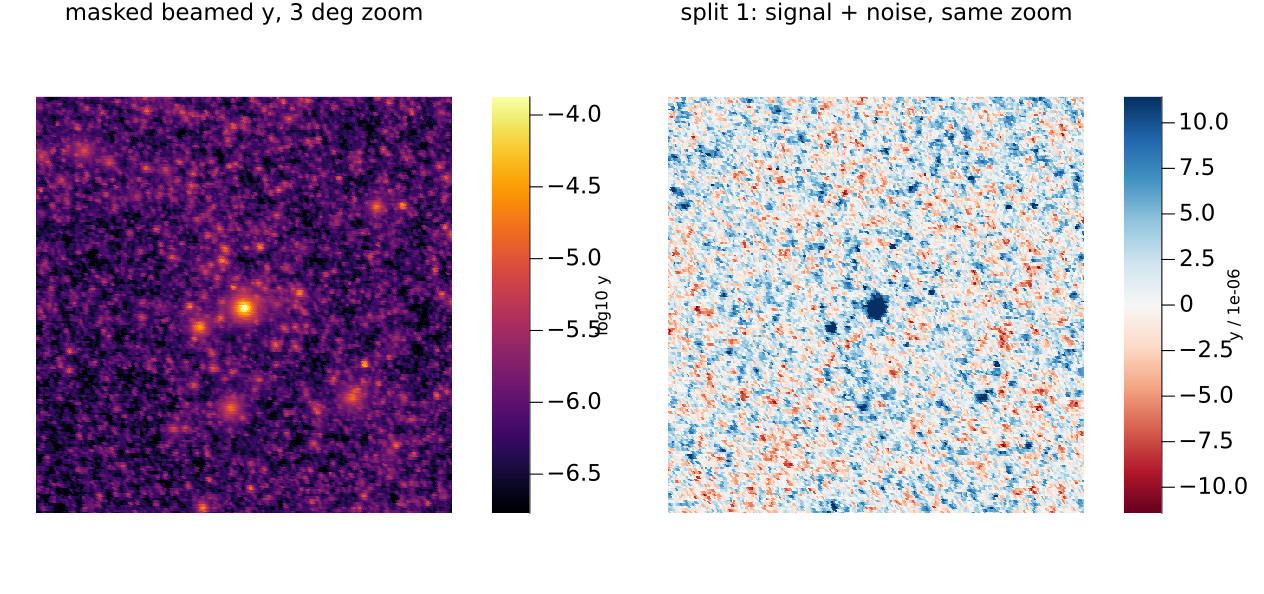

In [14]:
@printf("zoom centre (lat, lon) = (%.1f, %.1f) deg; mask weight there = %.3f\n", rad2deg(centre_masked[1]), rad2deg(centre_masked[2]),
        mask.pixels[Healpix.ang2pixRing(mask.resolution, pi / 2 - centre_masked[1], centre_masked[2])])
show_png(plot(show_zoom(signal, centre_masked; title="masked beamed y, 3 deg zoom"),
              show_zoom(splits[1], centre_masked; title="split 1: signal + noise, same zoom", log=false, cmap=:RdBu, symmetric=true);
              layout=(1, 2), size=(1150, 540)))

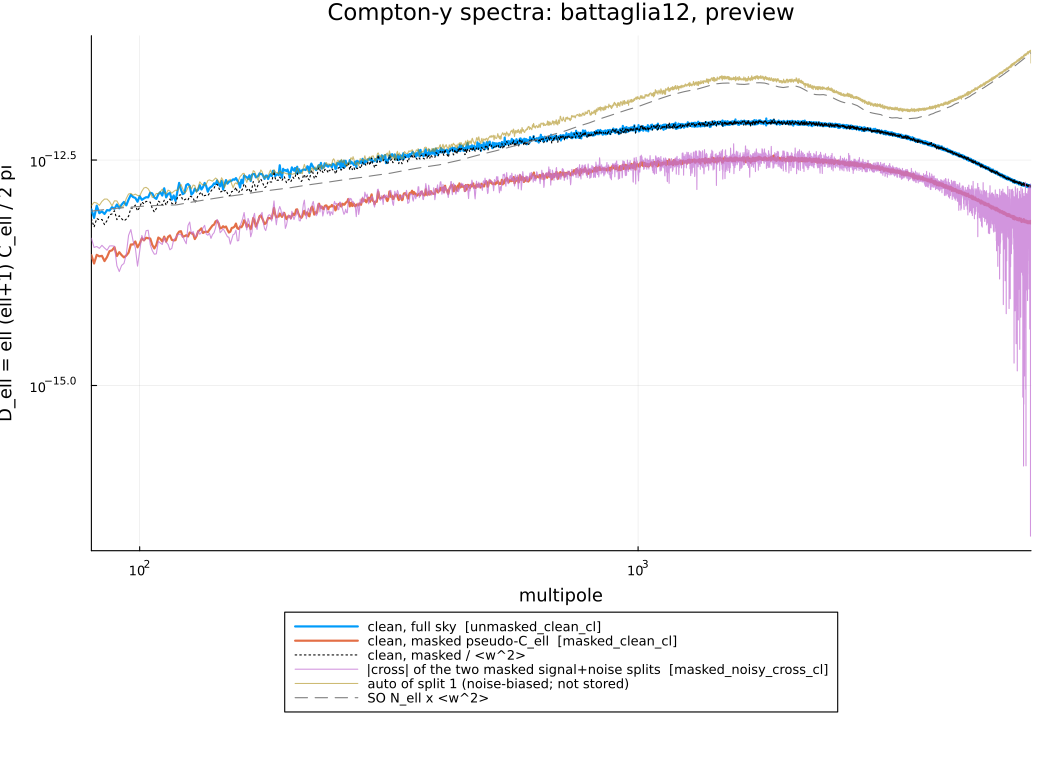

In [15]:
# ============== 8. power spectra (what the dataset keeps, plus two illustrations) ==============
ell = collect(80:P.lmax)
D   = dl_factor(ell)
dl(cl) = cl[ell .+ 1] .* D
plt = plot(xscale=:log10, yscale=:log10, xlabel="multipole", ylabel="D_ell = ell (ell+1) C_ell / 2 pi", legend=:outerbottom,
           legendfontsize=8, size=(950, 700), title=@sprintf("Compton-y spectra: %s%s, %s", THETA_SOURCE, THETA_SOURCE == :design_row ? " $DESIGN_ROW" : "", PRESET),
           xlims=(80, P.lmax))
plot!(plt, ell, dl(cl_unmasked), label="clean, full sky  [unmasked_clean_cl]", lw=2)
plot!(plt, ell, dl(cl_masked), label="clean, masked pseudo-C_ell  [masked_clean_cl]", lw=2)
plot!(plt, ell, dl(cl_masked) ./ mask_info.mean_weight2, label="clean, masked / <w^2>", ls=:dot, color=:black)
plot!(plt, ell, abs.(dl(cl_cross)), label="|cross| of the two masked signal+noise splits  [masked_noisy_cross_cl]", alpha=0.75)
plot!(plt, ell, dl(cl_auto1), label="auto of split 1 (noise-biased; not stored)", alpha=0.6)
plot!(plt, ell, noise_cl[ell .+ 1] .* D .* mask_info.mean_weight2, label="SO N_ell x <w^2>", ls=:dash, color=:gray)
show_png(plt)

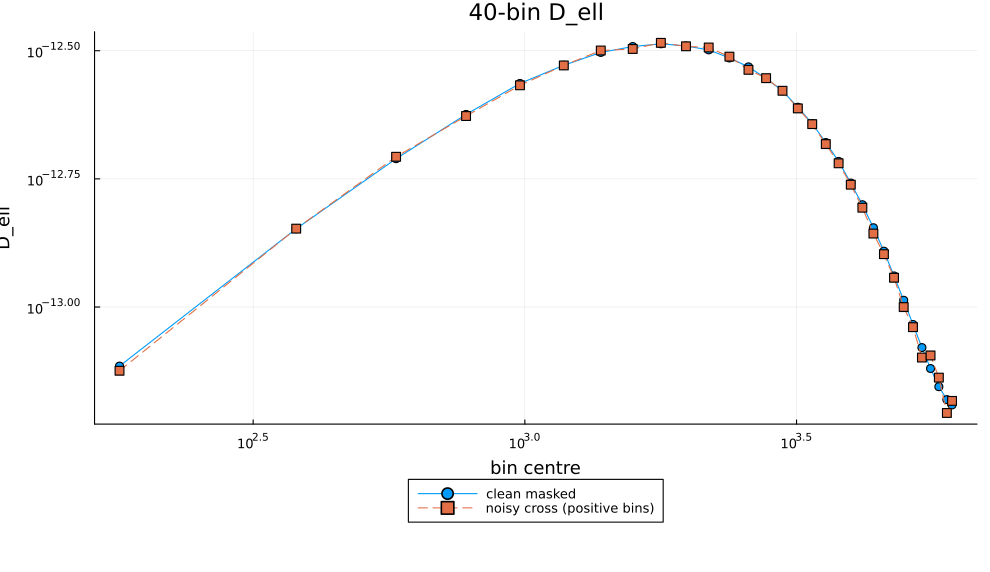

In [16]:
# The 40-bin summary used by the 256-row test (manage.py rebin_unbinned); the cross spectrum is signed.
xb, clean40 = rebin40(cl_masked; lmax=P.lmax)
_, cross40 = rebin40(cl_cross; lmax=P.lmax)
plt = plot(xscale=:log10, yscale=:log10, xlabel="bin centre", ylabel="D_ell", legend=:outerbottom, legendfontsize=8, size=(900, 520), title="40-bin D_ell")
plot!(plt, xb, clean40, marker=:circle, label="clean masked")
plot!(plt, xb[cross40 .> 0], cross40[cross40 .> 0], marker=:square, ls=:dash, label="noisy cross (positive bins)")
any(cross40 .<= 0) && scatter!(plt, xb[cross40 .<= 0], abs.(cross40[cross40 .<= 0]), marker=:xcross, color=:red, label="noisy cross (negative bins, |value|)")
show_png(plt)

In [17]:
# ============== 9. comparison with the 256-row test (design rows 0-255) ==============
# Rows 0-3 ship with the bundle (reference/test256/batch000); rows 0-255 are in the local snapshot of the 256-row test.
# The metric is manage.py spectrum_metrics: max over ell = 80..7979 of |new - ref| / (|ref| + clean ref); repro-check accepts < 1e-6.
function reference_dir(row)
    a = joinpath(BUNDLE, "reference", "test256", "batch000", @sprintf("%05d", row))
    b = joinpath(TEST256, "rows", @sprintf("%05d", row))
    isdir(a) ? a : isdir(b) ? b : nothing
end
if THETA_SOURCE == :design_row && DESIGN_ROW < 256 && reference_dir(DESIGN_ROW) !== nothing
    ref = reference_dir(DESIGN_ROW)
    ref_unmasked = read_npy(joinpath(ref, "unmasked_clean_cl.npy"))
    ref_masked   = read_npy(joinpath(ref, "masked_clean_cl.npy"))
    ref_cross    = read_npy(joinpath(ref, "masked_noisy_cross_cl.npy"))
    observation  = TOML.parsefile(joinpath(ref, "observation.toml"))
    metric(new, r, scale) = maximum(abs.(new[ell .+ 1] .- r[ell .+ 1]) ./ max.(abs.(r[ell .+ 1]) .+ abs.(scale[ell .+ 1]), floatmin()))
    if PRESET == :production
        @printf("max over ell of |new-ref|/(|ref|+clean ref): full-sky clean %.2e, masked clean %.2e, noisy cross %.2e\n",
                metric(cl_unmasked, ref_unmasked, ref_unmasked), metric(cl_masked, ref_masked, ref_masked), metric(cl_cross, ref_cross, ref_masked))
        println("mask identical to the test: ", mask_sha == observation["mask_sha256"])
        if NOISE_SEEDS == :test256
            println("noise splits bitwise identical to the test: ", noise_hashes == observation["noise_sha256"],
                    "  (repro-check reports this as informational: libsharp SIMD paths can differ in the last bit on other CPUs)")
        else
            println("noise seeds differ from the test ($NOISE_SEEDS), so only the two clean spectra are expected to agree")
        end
    else
        println("PRESET = $PRESET paints at NSIDE $(P.nside_raw) instead of 8192: the overlay below is a visual check only; use :production for the 1e-6 comparison")
    end
    plt = plot(xscale=:log10, yscale=:log10, xlabel="multipole", ylabel="D_ell", legend=:outerbottom, legendfontsize=8,
               size=(950, 640), title="this notebook vs the 256-row test on idark, row $DESIGN_ROW")
    plot!(plt, ell, dl(cl_unmasked), label="full-sky clean (here)", lw=2)
    plot!(plt, ell, ref_unmasked[ell .+ 1] .* D, label="full-sky clean (test)", ls=:dash, color=:black)
    plot!(plt, ell, dl(cl_masked), label="masked clean (here)", lw=2)
    plot!(plt, ell, ref_masked[ell .+ 1] .* D, label="masked clean (test)", ls=:dash, color=:gray)
    plot!(plt, ell, abs.(dl(cl_cross)), label="|noisy cross| (here)", alpha=0.6)
    plot!(plt, ell, abs.(ref_cross[ell .+ 1] .* D), label="|noisy cross| (test)", ls=:dot, color=:red, alpha=0.8)
    show_png(plt)
else
    println("no reference for this parameter choice: references exist for design rows 0-255 (THETA_SOURCE = :design_row)")
end

no reference for this parameter choice: references exist for design rows 0-255 (THETA_SOURCE = :design_row)


In [18]:
# ============== 10. release memory ==============
signal = nothing; splits = nothing; mask = nothing; mask_info = nothing; profile = nothing
GC.gc(); GC.gc()
println("released; ", mem(), ". Timings (s): ", join(["$k=$(round(v; digits=1))" for (k, v) in sort(collect(TIMINGS))], ", "))

released; 27.3 GiB free of 31.2 GiB

. Timings (s): painting=179.4, raw_map2alm=16.4, read_mass_redshift=1.9, read_positions=3.8, selection=1.0, signal_alm2map=9.0


## Notes

- To look at another profile, change the settings cell and rerun from the top (the kernel keeps the engine loaded, so the
  reruns skip the compile time; the catalogue pass is repeated).
- `:production` with a design row 0-255 and `NOISE_SEEDS = :test256` is a local repro-check: on idark the same rows agree
  with the test to about 1e-13 (clean) and 1e-10 (noisy cross), against a 1e-6 tolerance.
- The dataset engine paints four rows per catalogue pass with shared halo geometry (`paint_shared!` with four profiles).
  Painting one row here uses the same function with a single profile; the pressure arithmetic is identical.
- What the dataset never stores and this notebook shows: the raw map, the beamed map, the mask, the noise maps and the
  auto-spectra. What it stores per row: the three spectra of section 8, `observation.toml` and `status.json`.